In [1]:
library(gamlss)
library(readxl)
library(writexl)

NameError: name 'library' is not defined

In [2]:
male <- read_excel("/home/okta/Documents/data-analysis/doni/male/male_data.xlsx")
male

ks,tl,umur,sex,tb,bb,bf,bmi
<chr>,<dttm>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
SM71,2013-06-24,12.3,M,143.0,39.5,13.4,19.3
SM72,2012-10-01,13.0,M,147.5,37.5,11.1,17.2
SM73,2012-12-22,12.8,M,158.0,41.8,8.1,16.7
SM74,2013-02-14,12.6,M,160.0,64.7,22.0,25.3
SM75,2013-04-30,12.4,M,145.0,45.3,0.0,21.5
SM76,2012-10-28,12.9,M,166.5,69.5,27.8,25.1
SM77,2012-10-10,12.9,M,148.0,42.3,11.4,19.3
SM78,2013-03-27,12.5,M,155.5,44.4,12.2,18.4
SM79,2013-02-02,12.7,M,147.5,51.2,23.4,23.5


In [3]:
tb_bcpe <- gamlss(
    tb ~ pb(umur),
    sigma.formula = ~ pb(umur),
    nu.formula = ~pb(umur),
    tau.formula = ~1, 
    family = BCPE, 
    data = male, 
    method = mixed(2, 40))

GAMLSS-RS iteration 1: Global Deviance = 5651.713 
GAMLSS-RS iteration 2: Global Deviance = 5625.549 
GAMLSS-CG iteration 1: Global Deviance = 5624.18 
GAMLSS-CG iteration 2: Global Deviance = 5623.936 
GAMLSS-CG iteration 3: Global Deviance = 5623.887 
GAMLSS-CG iteration 4: Global Deviance = 5623.872 
GAMLSS-CG iteration 5: Global Deviance = 5623.866 
GAMLSS-CG iteration 6: Global Deviance = 5623.864 
GAMLSS-CG iteration 7: Global Deviance = 5623.863 


In [1]:
round(Q.stats(tb_bcpe, male$umur), 3)

SyntaxError: invalid syntax (3445849181.py, line 1)

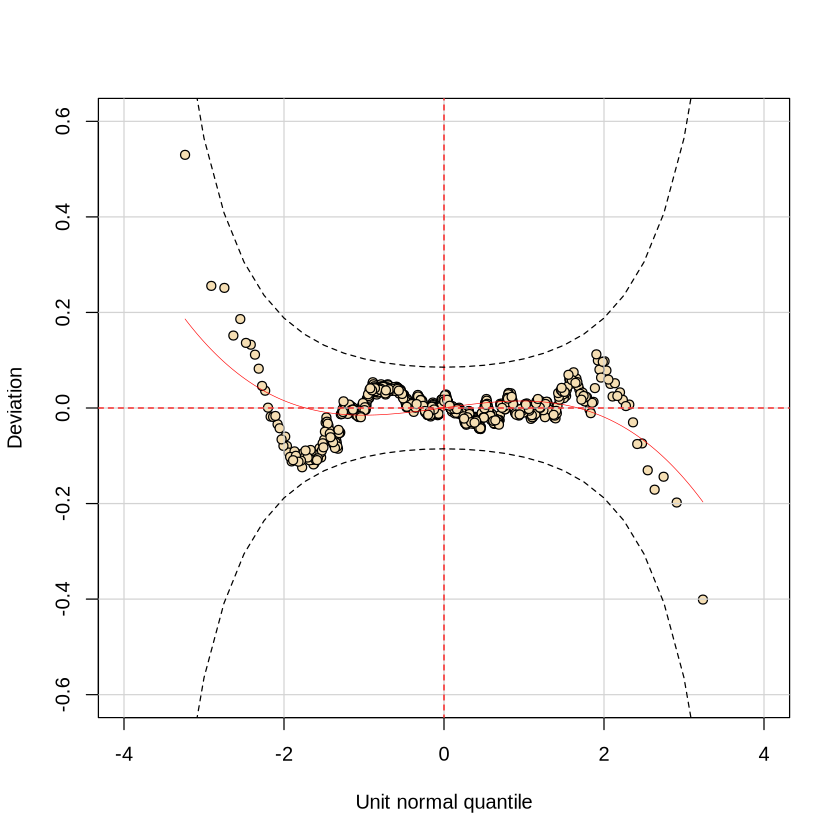

In [5]:
wp(tb_bcpe, ylim.all=0.6)

% of cases below  0.4 centile is  0.241838 
% of cases below  2 centile is  2.297461 
% of cases below  10 centile is  10.15719 
% of cases below  25 centile is  23.5792 
% of cases below  50 centile is  49.45586 
% of cases below  75 centile is  75.69528 
% of cases below  90 centile is  89.96372 
% of cases below  98 centile is  97.58162 
% of cases below  99.6 centile is  99.75816 


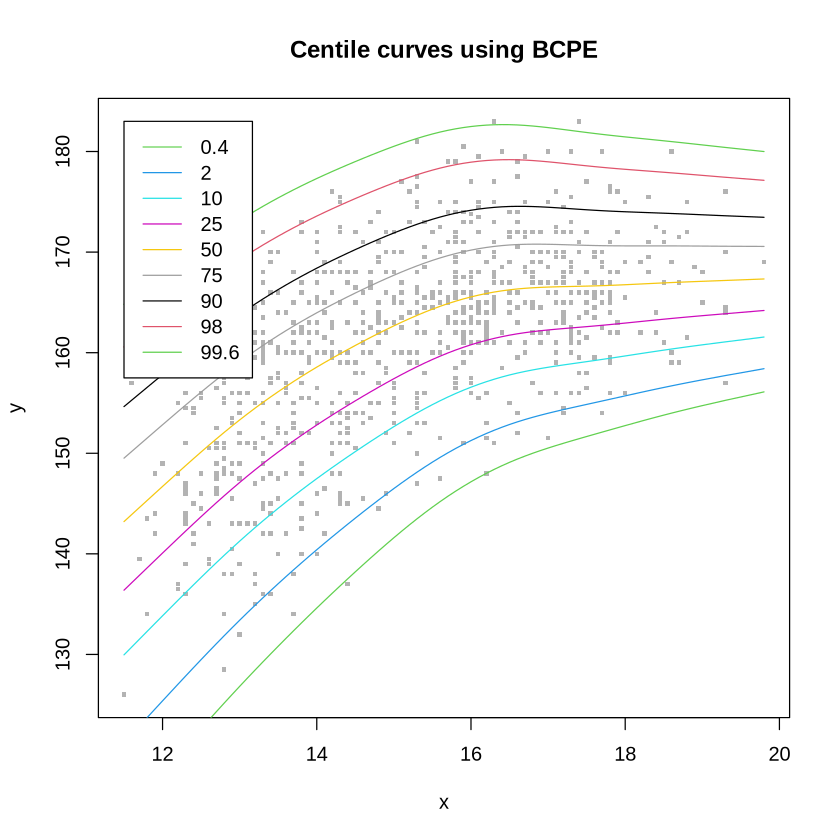

In [6]:
centiles(tb_bcpe)

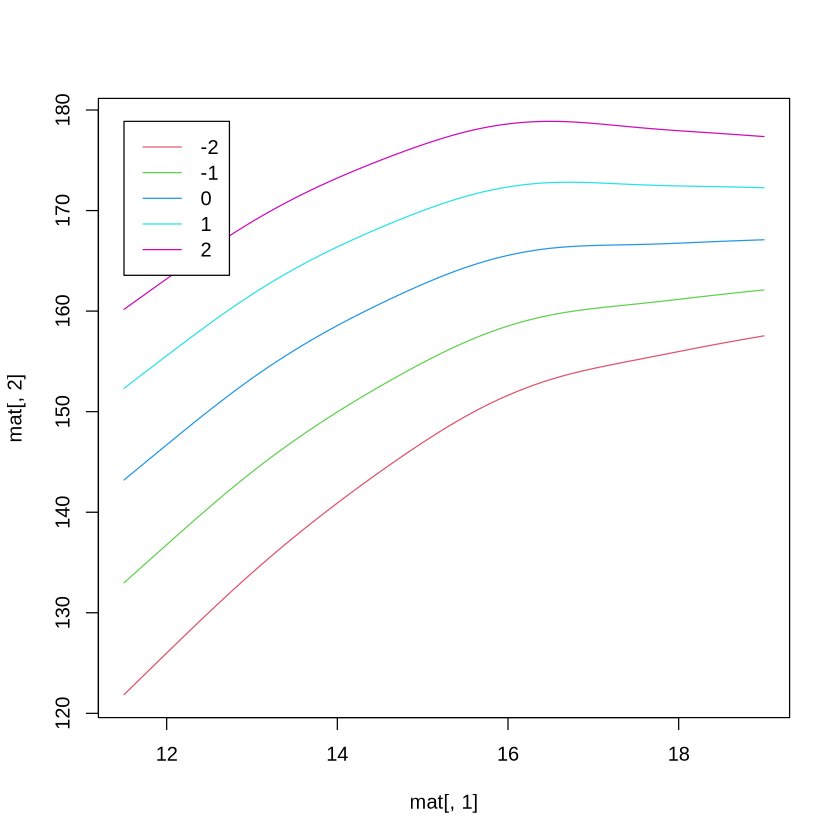

In [7]:
Z_scores <- c(-2, -1, 0, 1, 2)

seq_umur <- seq(from=11.5, to=19, by=0.1)

# prediksi z-score
zscore_tb_male <- centiles.pred(
    obj=tb_bcpe,
    xname="umur",
    xvalues=seq_umur,
    type="standard-centiles",
    dev = Z_scores,
    plot=TRUE)

In [8]:
library(tidyr)
library(dplyr)

tb_df_male <- as.data.frame(zscore_tb_male)
colnames(tb_df_male) <- c("umur", paste0("Z", Z_scores))

tb_df_male_long  <- tb_df_male %>%
  pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
  mutate(Source = "local_male_tb")

tb_df_male_long


Attaching package: ‘dplyr’


The following object is masked from ‘package:nlme’:

    collapse


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,121.8560,local_male_tb
11.5,Z-1,132.9785,local_male_tb
11.5,Z0,143.2075,local_male_tb
11.5,Z1,152.3215,local_male_tb
11.5,Z2,160.1767,local_male_tb
11.6,Z-2,122.6859,local_male_tb
11.6,Z-1,133.7387,local_male_tb
11.6,Z0,143.9083,local_male_tb
11.6,Z1,152.9716,local_male_tb


In [9]:
write_xlsx(tb_df_male_long, "zscore_tb_male.xlsx")

In [22]:
who_male <- read_excel("/home/okta/Documents/data-analysis/doni/male/hfa-boys-z-who-2007-exp.xlsx") 
who_male

Month,L,M,S,StDev,SD5neg,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
61,1,110.2647,0.04164,4.5914,87.308,91.899,96.490,101.082,105.673,110.265,114.856,119.448,124.039,128.630
62,1,110.8006,0.04172,4.6226,87.688,92.310,96.933,101.555,106.178,110.801,115.423,120.046,124.668,129.291
63,1,111.3338,0.04180,4.6538,88.065,92.719,97.373,102.026,106.680,111.334,115.988,120.641,125.295,129.949
64,1,111.8636,0.04187,4.6837,88.445,93.129,97.812,102.496,107.180,111.864,116.547,121.231,125.915,130.599
65,1,112.3895,0.04195,4.7147,88.816,93.531,98.245,102.960,107.675,112.390,117.104,121.819,126.534,131.248
66,1,112.9110,0.04203,4.7456,89.183,93.928,98.674,103.420,108.165,112.911,117.657,122.402,127.148,131.894
67,1,113.4280,0.04211,4.7765,89.546,94.322,99.099,103.875,108.652,113.428,118.204,122.981,127.757,132.534
68,1,113.9410,0.04218,4.8060,89.911,94.717,99.523,104.329,109.135,113.941,118.747,123.553,128.359,133.165
69,1,114.4500,0.04226,4.8367,90.267,95.103,99.940,104.777,109.613,114.450,119.287,124.123,128.960,133.797


In [24]:
# Pilih kolom yang akan digunakan dan ubah nama kolom agar konsisten
who_tb <- who_male %>%
     select(Month, SD2neg, SD1neg, SD0, SD2, SD1) %>%
     rename(
         'umur' = Month,
         'Z-2' = SD2neg,
         'Z-1' = SD1neg,
         'Z0' = SD0,
         'Z1' = SD1,
         'Z2' = SD2
         )

# Ubah format data menjadi long
who_tb_long <- who_tb %>%
     pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
     mutate(Source="WHO_tb_male")

who_tb_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
61,Z-2,101.082,WHO_tb_male
61,Z-1,105.673,WHO_tb_male
61,Z0,110.265,WHO_tb_male
61,Z2,119.448,WHO_tb_male
61,Z1,114.856,WHO_tb_male
62,Z-2,101.555,WHO_tb_male
62,Z-1,106.178,WHO_tb_male
62,Z0,110.801,WHO_tb_male
62,Z2,120.046,WHO_tb_male


In [25]:
who_tb_long$umur<-who_tb_long$umur/12

In [26]:
who_tb_long$umur <- round(who_tb_long$umur, 2)
who_tb_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
5.08,Z-2,101.082,WHO_tb_male
5.08,Z-1,105.673,WHO_tb_male
5.08,Z0,110.265,WHO_tb_male
5.08,Z2,119.448,WHO_tb_male
5.08,Z1,114.856,WHO_tb_male
5.17,Z-2,101.555,WHO_tb_male
5.17,Z-1,106.178,WHO_tb_male
5.17,Z0,110.801,WHO_tb_male
5.17,Z2,120.046,WHO_tb_male


In [27]:
who_male_tb1219 <- who_tb_long %>%
  filter(umur >= 11.5, umur <= 19)

who_male_tb1219$umur <- round(who_male_tb1219$umur, 2)
who_male_tb1219

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.50,Z-2,132.173,WHO_tb_male
11.50,Z-1,139.081,WHO_tb_male
11.50,Z0,145.989,WHO_tb_male
11.50,Z2,159.806,WHO_tb_male
11.50,Z1,152.897,WHO_tb_male
11.58,Z-2,132.612,WHO_tb_male
11.58,Z-1,139.550,WHO_tb_male
11.58,Z0,146.488,WHO_tb_male
11.58,Z2,160.363,WHO_tb_male


In [28]:
tb_male_zscore_gabungan1219 <- bind_rows(tb_df_male_long, who_male_tb1219)
tb_male_zscore_gabungan1219

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,121.8560,local_male_tb
11.5,Z-1,132.9785,local_male_tb
11.5,Z0,143.2075,local_male_tb
11.5,Z1,152.3215,local_male_tb
11.5,Z2,160.1767,local_male_tb
11.6,Z-2,122.6859,local_male_tb
11.6,Z-1,133.7387,local_male_tb
11.6,Z0,143.9083,local_male_tb
11.6,Z1,152.9716,local_male_tb


In [29]:
write_xlsx(tb_male_zscore_gabungan1219, "clean_data/male_tb_gabungan1219.xlsx")

## BMI

In [30]:
bmi_male <- gamlss(formula = bmi ~ pb(umur), 
                   sigma.formula = ~1,
                   nu.formula = ~pb(umur), 
                   tau.formula = ~1, 
                   family = BCPE,
                   data = male) 

GAMLSS-RS iteration 1: Global Deviance = 4655.517 
GAMLSS-RS iteration 2: Global Deviance = 4572.262 
GAMLSS-RS iteration 3: Global Deviance = 4552.398 
GAMLSS-RS iteration 4: Global Deviance = 4547.169 
GAMLSS-RS iteration 5: Global Deviance = 4546.039 
GAMLSS-RS iteration 6: Global Deviance = 4545.813 
GAMLSS-RS iteration 7: Global Deviance = 4545.732 
GAMLSS-RS iteration 8: Global Deviance = 4545.714 
GAMLSS-RS iteration 9: Global Deviance = 4545.71 
GAMLSS-RS iteration 10: Global Deviance = 4545.709 
GAMLSS-RS iteration 11: Global Deviance = 4545.708 


,Z1,Z2,Z3,Z4,AgostinoK2,N
11.45 to 12.95,0.592,0.950,-0.139,-2.341,5.501,93
12.95 to 13.35,-0.467,1.014,-1.949,2.036,7.944,76
13.35 to 14.05,-1.203,0.831,1.632,-0.733,3.200,94
14.05 to 14.55,-1.399,-1.926,0.304,-0.310,0.189,73
14.55 to 15.25,1.189,-1.252,1.709,-0.163,2.946,79
15.25 to 15.85,0.261,-1.844,-0.093,-1.027,1.063,88
15.85 to 16.35,-0.850,0.238,0.688,1.230,1.986,94
16.35 to 16.95,0.259,0.226,0.161,0.791,0.651,70
16.95 to 17.55,1.345,1.080,-1.404,0.440,2.165,83
17.55 to 19.85,-0.720,-0.415,0.334,-1.337,1.900,77


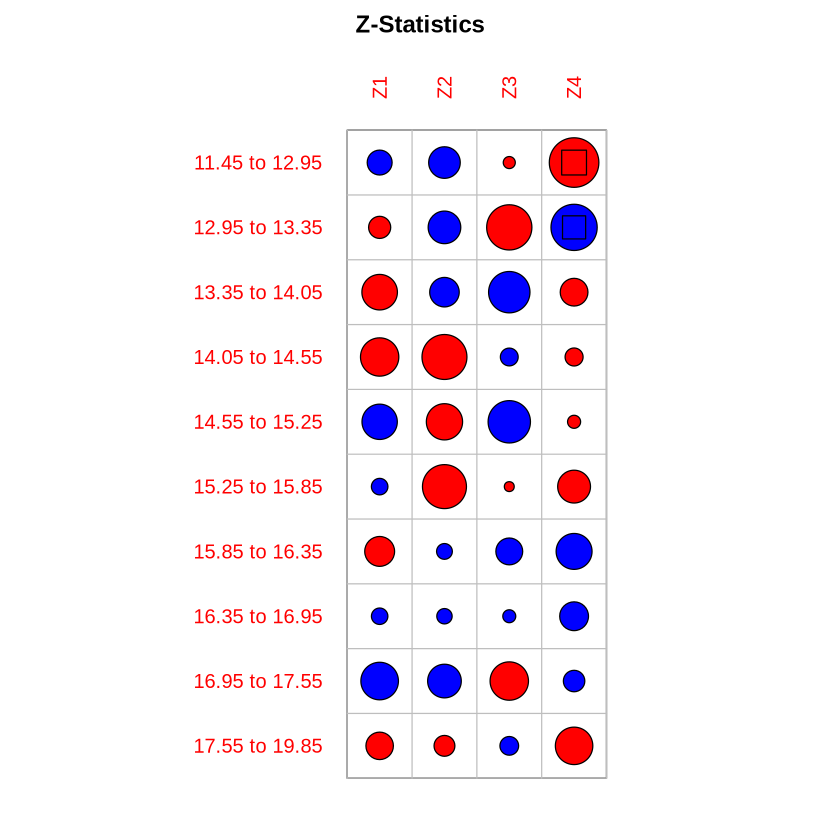

In [31]:
round(Q.stats(bmi_male, male$umur), 3)

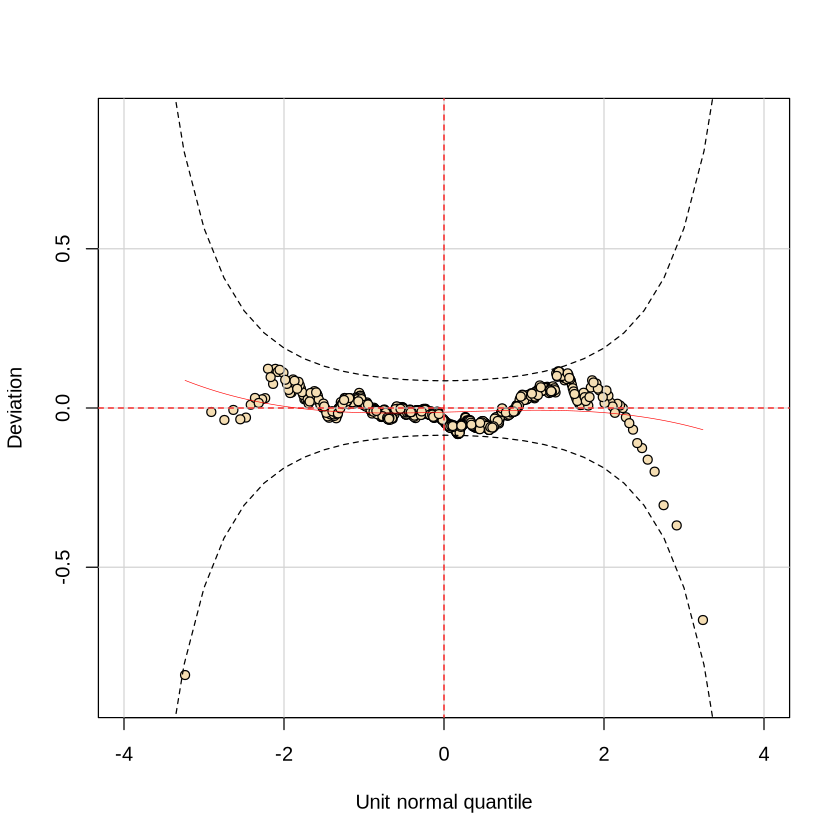

In [32]:
wp(bmi_male, ylim.all=0.9)

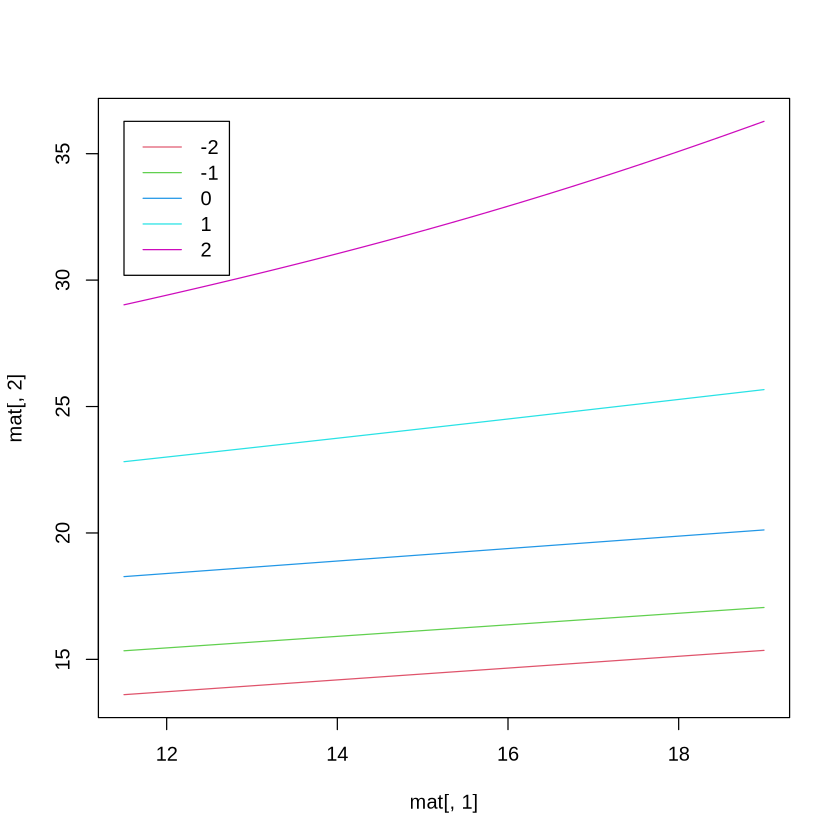

In [35]:
Z_scores <- c(-2, -1, 0, 1, 2)

seq_umur <- seq(from=11.5, to=19, by=0.1)

# prediksi z-score
zscore_bmi_male <- centiles.pred(
    obj=bmi_male,
    xname="umur",
    xvalues=seq_umur,
    type="standard-centiles",
    dev = Z_scores,
    plot=TRUE)

In [36]:
bmi_df_male <- as.data.frame(zscore_bmi_male)
colnames(bmi_df_male) <- c("umur", paste0("Z", Z_scores))

bmi_male_long  <- bmi_df_male %>%
  pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
  mutate(Source="local_male_bmi.xlsx")

bmi_male_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,13.60474,local_male_bmi.xlsx
11.5,Z-1,15.34024,local_male_bmi.xlsx
11.5,Z0,18.27336,local_male_bmi.xlsx
11.5,Z1,22.81857,local_male_bmi.xlsx
11.5,Z2,29.02282,local_male_bmi.xlsx
11.6,Z-2,13.62812,local_male_bmi.xlsx
11.6,Z-1,15.36303,local_male_bmi.xlsx
11.6,Z0,18.29802,local_male_bmi.xlsx
11.6,Z1,22.85525,local_male_bmi.xlsx


In [38]:
write_xlsx(bmi_male_long, "clean_data/zscore_bmi_male.xlsx")

#### WHO

In [40]:
who_male_bmi <- read_excel("/home/okta/Documents/data-analysis/doni/male/bmi-boys-z-who-2007-exp.xlsx") 
who_male_bmi

Month,L,M,S,SD4neg,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3,SD4
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
61,-0.7387,15.2641,0.08390,11.204,12.118,13.031,14.071,15.264,16.645,18.259,20.166,22.072
62,-0.7621,15.2616,0.08414,11.204,12.115,13.027,14.066,15.262,16.648,18.273,20.200,22.127
63,-0.7856,15.2604,0.08439,11.204,12.114,13.024,14.063,15.260,16.653,18.290,20.238,22.186
64,-0.8089,15.2605,0.08464,11.205,12.114,13.022,14.061,15.260,16.659,18.308,20.277,22.247
65,-0.8322,15.2619,0.08490,11.207,12.114,13.021,14.060,15.262,16.667,18.328,20.320,22.312
66,-0.8554,15.2645,0.08516,11.210,12.115,13.021,14.060,15.264,16.676,18.350,20.365,22.380
67,-0.8785,15.2684,0.08543,11.213,12.117,13.021,14.061,15.268,16.686,18.374,20.413,22.452
68,-0.9015,15.2737,0.08570,11.218,12.121,13.023,14.063,15.274,16.699,18.399,20.463,22.526
69,-0.9243,15.2801,0.08597,11.223,12.125,13.026,14.067,15.280,16.712,18.427,20.515,22.604


In [43]:
# Pilih kolom yang akan digunakan dan ubah nama kolom agar konsisten
who_bmi_male <- who_male_bmi %>%
     select(Month, SD2neg, SD1neg, SD0, SD1, SD2) %>%
     rename(
         'umur' = Month,
         'Z-2' = SD2neg,
         'Z-1' = SD1neg,
         'Z0' = SD0,
         'Z1' = SD1,
         'Z2' = SD2
         )

# Ubah format data menjadi long
who_bmi_male_long <- who_bmi_male %>%
     pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
     mutate(Source="WHO_tb_male")

who_bmi_male_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
61,Z-2,13.031,WHO_tb_male
61,Z-1,14.071,WHO_tb_male
61,Z0,15.264,WHO_tb_male
61,Z1,16.645,WHO_tb_male
61,Z2,18.259,WHO_tb_male
62,Z-2,13.027,WHO_tb_male
62,Z-1,14.066,WHO_tb_male
62,Z0,15.262,WHO_tb_male
62,Z1,16.648,WHO_tb_male


In [44]:
who_bmi_male_long$umur <- who_bmi_male_long$umur/12

In [45]:
who_bmi_male_long

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
5.083333,Z-2,13.031,WHO_tb_male
5.083333,Z-1,14.071,WHO_tb_male
5.083333,Z0,15.264,WHO_tb_male
5.083333,Z1,16.645,WHO_tb_male
5.083333,Z2,18.259,WHO_tb_male
5.166667,Z-2,13.027,WHO_tb_male
5.166667,Z-1,14.066,WHO_tb_male
5.166667,Z0,15.262,WHO_tb_male
5.166667,Z1,16.648,WHO_tb_male


In [46]:
# filter
who_male_bmi1219 <- who_bmi_male_long %>%
  filter(umur >= 11.5, umur <= 19)

who_male_bmi1219$umur <- round(who_male_bmi1219$umur, 2)
who_male_bmi1219

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.50,Z-2,14.245,WHO_tb_male
11.50,Z-1,15.539,WHO_tb_male
11.50,Z0,17.224,WHO_tb_male
11.50,Z1,19.542,WHO_tb_male
11.50,Z2,23.009,WHO_tb_male
11.58,Z-2,14.278,WHO_tb_male
11.58,Z-1,15.578,WHO_tb_male
11.58,Z0,17.273,WHO_tb_male
11.58,Z1,19.607,WHO_tb_male


In [47]:
write_xlsx(who_male_bmi1219, "clean_data/who_male_bmi_umur1219.xlsx")

In [48]:
bmi_male_gabungan1219 <- bind_rows(bmi_male_long, who_male_bmi1219)

In [49]:
write_xlsx(bmi_male_gabungan1219, "clean_data/bmi_male_gabungan1219.xlsx")